# Seção 4: Modelagem com Machine Learning
## Classificação da Via de Transporte das Exportações Brasileiras (LightGBM)

Este notebook implementa o modelo LightGBM (gradient boosting) para a tarefa de modelagem preditiva do projeto, que é um dos três algoritmos comparados pelo grupo:

1. Regressão Logística (baseline linear interpretável)
2. Random Forest (ensemble por bagging)
3. LightGBM (ensemble por boosting), implementado neste notebook

### Pergunta de pesquisa (RQ2)
 É possível classificar a via de transporte principal (CO_VIA) utilizada em uma operação de exportação com base nas características físicas da carga (KG_LIQUIDO), na localização geográfica de origem (SG_UF_NCM) e no valor declarado (VL_FOB)?

### Hipótese associada (H2)
 As características físicas da carga (KG_LIQUIDO) e a localização geográfica de origem (SG_UF_NCM) são os preditores com maior peso estatístico para classificar a via de transporte (CO_VIA), superando o impacto do valor declarado (VL_FOB).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
from pathlib import Path

RANDOM_STATE = 42
DATA_PATH = Path('../data/exports_tidy.parquet')
RESULTS_DIR = Path('../results')
RESULTS_DIR.mkdir(exist_ok=True)

sns.set_theme(style='white')
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

print('Versoes:')
print(f'  pandas    {pd.__version__}')
print(f'  numpy     {np.__version__}')
print(f'  lightgbm  {lgb.__version__}')

Versoes:
  pandas    3.0.3
  numpy     2.4.6
  lightgbm  4.6.0


## 1. Carregamento dos dados

É utilizado o dataset tidy já limpo e enriquecido na Etapa 3 (exports_tidy.parquet), com 1.709.746 registros de exportações brasileiras de 2025 e 23 colunas, incluindo features derivadas como value_per_kg, origin_region, is_mercosul e is_coastal_state.

In [2]:
df = pd.read_parquet(DATA_PATH)
print(f'Registros: {df.shape[0]:,}  |  Colunas: {df.shape[1]}')
df.head()

Registros: 1,709,746  |  Colunas: 23


,year,month,ncm_code,statistical_unit_code_export,country_code,origin_state,transport_route,urf_code,statistical_quantity,net_weight_kg,...,quarter,semester,origin_region,ncm_chapter,is_mercosul,is_coastal_state,is_express_delivery,statistical_unit_code_ncm,ncm_name_ptbr,country_name
0,2025,8,71039900,19,687,RS,4,817700,61690,13.0000,...,3,2,South,71,False,True,False,19,Outras pedras preciosas (exceto diamantes) ou ...,El Salvador
1,2025,12,2071412,10,741,SC,1,817800,83835,"83,835.0000",...,4,2,South,2,False,True,False,10,Coxas com sobrecoxas não desossadas de galinha...,Singapura
2,2025,11,33059000,10,767,SP,4,817600,792,753.0000,...,4,2,Southeast,33,False,True,False,10,Outras preparações capilares,Suíça
3,2025,11,56031330,10,845,SP,7,1017701,2437,"2,437.0000",...,4,2,Southeast,56,False,True,False,10,"Falsos tecidos de poliéster, de peso superior ...",Uruguai
4,2025,6,21069090,10,365,SP,1,817800,4800,"4,800.0000",...,2,1,Southeast,21,False,True,False,10,Outras preparações alimentícias,Indonésia


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1709746 entries, 0 to 1709745
Data columns (total 23 columns):
 #   Column                        Dtype  
---  ------                        -----  
 0   year                          int64  
 1   month                         int64  
 2   ncm_code                      int64  
 3   statistical_unit_code_export  int64  
 4   country_code                  int64  
 5   origin_state                  str    
 6   transport_route               str    
 7   urf_code                      int64  
 8   statistical_quantity          int64  
 9   net_weight_kg                 float64
 10  fob_value_usd                 float64
 11  month_name                    str    
 12  value_per_kg                  float64
 13  quarter                       int64  
 14  semester                      int64  
 15  origin_region                 str    
 16  ncm_chapter                   int64  
 17  is_mercosul                   bool   
 18  is_coastal_state              boo

## 2. Construção da variável alvo (route_class)

A coluna transport_route (CO_VIA) é fortemente desbalanceada. A distribuição original completa, antes de qualquer agrupamento, é mostrada a seguir: três modais concentram cerca de 98% dos registros, enquanto a cauda contém classes com percentuais minúsculos, algumas com apenas 2 registros.

In [4]:
# Distribuicao original de transport_route (CO_VIA), antes do agrupamento
VIA_NAMES = {
    '1': 'MARITIMA', '4': 'AEREA', '7': 'RODOVIARIA', '15': 'VICINAL_FRONTEIRICO',
    '0': 'VIA NAO DECLARADA', '12': 'EM MAOS', '6': 'FERROVIARIA', '9': 'MEIOS PROPRIOS',
    '3': 'LACUSTRE', '2': 'FLUVIAL', '8': 'CONDUTO/REDE', '13': 'POR REBOQUE',
}
raw_dist = df['transport_route'].value_counts()
raw_tab = pd.DataFrame({
    'codigo': [str(c) for c in raw_dist.index],
    'via': [VIA_NAMES.get(str(c), 'OUTRO') for c in raw_dist.index],
    'registros': raw_dist.values,
    'percentual_%': (raw_dist.values / len(df) * 100).round(3),
})
raw_tab

,codigo,via,registros,percentual_%
0,1,MARITIMA,913761,53.4440
1,4,AEREA,466747,27.2990
2,7,RODOVIARIA,290955,17.0170
3,15,VICINAL_FRONTEIRICO,19913,1.1650
4,0,VIA NAO DECLARADA,16902,0.9890
5,12,EM MAOS,528,0.0310
6,6,FERROVIARIA,411,0.0240
7,9,MEIOS PROPRIOS,280,0.0160
8,3,LACUSTRE,133,0.0080
9,2,FLUVIAL,86,0.0050


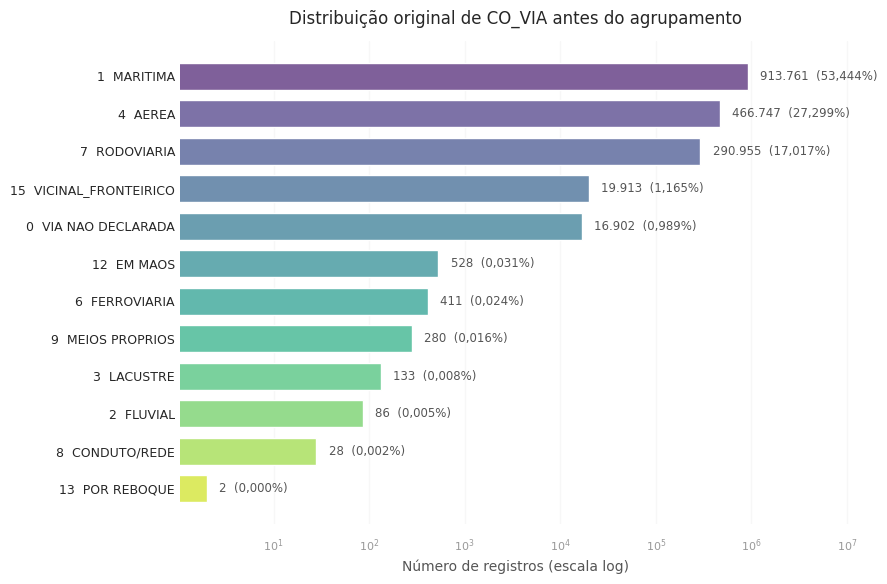

In [5]:
# Grafico da distribuicao original (escala log para enxergar as classes raras)
def lighten(color, amount=0.3):
    c = np.array(mcolors.to_rgb(color))
    return tuple(c + (1.0 - c) * amount)

def br_num(v):
    return f'{v:,.0f}'.replace(',', '.')

order = raw_tab.sort_values('registros', ascending=False)
labels = [f'{r.codigo}  {r.via}' for r in order.itertuples()]
vals = order['registros'].values
pcts = order['percentual_%'].values
colors = [lighten(c, 0.3) for c in sns.color_palette('viridis', len(vals))]

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(labels, vals, color=colors, edgecolor='white', height=0.72)
ax.set_xscale('log')
ax.invert_yaxis()
ax.set_xlim(right=vals.max() * 12)
for bar, v, p in zip(bars, vals, pcts):
    pc = f'{p:.3f}'.replace('.', ',')
    ax.text(bar.get_width() * 1.35, bar.get_y() + bar.get_height() / 2,
            f'{br_num(v)}  ({pc}%)', va='center', ha='left', fontsize=8.5, color='#555555')
ax.set_xlabel('Número de registros (escala log)', fontsize=10, color='#555555')
ax.set_title('Distribuição original de CO_VIA antes do agrupamento', fontsize=12, pad=12)
ax.tick_params(axis='y', length=0, labelsize=9)
ax.tick_params(axis='x', colors='#999999', labelsize=8)
sns.despine(left=True, bottom=True)
ax.grid(axis='x', alpha=0.15)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'raw_transport_route_distribution.png', dpi=140, bbox_inches='tight')
plt.show()

Diante dessa distribuição, para tornar o problema tratável e a métrica F1-macro significativa, foram tomadas as seguintes decisões:

1. Remover a categoria 00 (VIA NAO DECLARADA), cerca de 1% dos dados. Não é um modal real, e sim ausência de informação no alvo, então mantê-la poluiria o target.
2. Manter como classes próprias os modais com suporte suficiente: MARITIMA (01), AEREA (04), RODOVIARIA (07) e VICINAL_FRONTEIRICO (15, cerca de 20 mil registros).
3. Agrupar em OUTROS a cauda genuinamente minúscula (fluvial, lacustre, ferroviária, conduto, meios próprios, em mãos e por reboque), evitando classes não treináveis.

Resultado: 5 classes cobrindo cerca de 99% dos dados.

In [6]:
# Mapeamento CO_VIA -> classe alvo. Codigos nao listados caem em 'OUTROS'.
ROUTE_NAMES = {1: 'MARITIMA', 4: 'AEREA', 7: 'RODOVIARIA', 15: 'VICINAL_FRONTEIRICO'}
DROP_CODE = 0 

def to_route_class(code):
    c = int(code)
    if c == DROP_CODE:
        return None
    return ROUTE_NAMES.get(c, 'OUTROS')

n_before = len(df)
df['route_class'] = df['transport_route'].map(to_route_class)
n_removed = int(df['route_class'].isna().sum())
df = df.dropna(subset=['route_class']).reset_index(drop=True)

print(f'Linhas antes: {n_before:,}')
print(f'Removidas (00, nao declarada): {n_removed:,}')
print(f'Linhas apos limpeza do alvo: {len(df):,}')

Linhas antes: 1,709,746
Removidas (00, nao declarada): 16,902
Linhas apos limpeza do alvo: 1,692,844


In [7]:
# Distribuicao das 5 classes do target
dist = df['route_class'].value_counts()
dist_pct = (dist / len(df) * 100).round(2)
dist_table = pd.DataFrame({'registros': dist, 'percentual_%': dist_pct})
dist_table

,registros,percentual_%
route_class,,
MARITIMA,913761,53.9800
AEREA,466747,27.5700
RODOVIARIA,290955,17.1900
VICINAL_FRONTEIRICO,19913,1.1800
OUTROS,1468,0.0900


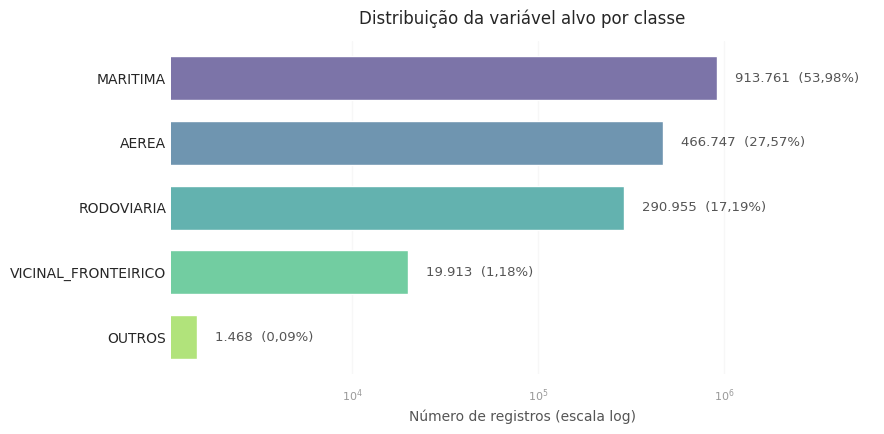

In [8]:
# Visualizacao da distribuicao (escala log para enxergar as classes raras)
def lighten(color, amount=0.3):
    c = np.array(mcolors.to_rgb(color))
    return tuple(c + (1.0 - c) * amount)

def br_num(v):
    return f'{v:,.0f}'.replace(',', '.')

order = dist.index.tolist()
base_colors = sns.color_palette('viridis', len(order))
colors = [lighten(c, 0.3) for c in base_colors]

fig, ax = plt.subplots(figsize=(9, 4.5))
bars = ax.barh(order, dist.values, color=colors, edgecolor='white', height=0.68)
ax.set_xscale('log')
ax.invert_yaxis()
ax.set_xlim(right=dist.values.max() * 7)

for bar, v, p in zip(bars, dist.values, dist_pct.values):
    pct = f'{p:.2f}'.replace('.', ',')
    ax.text(bar.get_width() * 1.25, bar.get_y() + bar.get_height() / 2,
            f'{br_num(v)}  ({pct}%)', va='center', ha='left',
            fontsize=9.5, color='#555555')

ax.set_xlabel('Número de registros (escala log)', fontsize=10, color='#555555')
ax.set_title('Distribuição da variável alvo por classe', fontsize=12, pad=12)
ax.tick_params(axis='y', length=0, labelsize=10)
ax.tick_params(axis='x', colors='#999999', labelsize=8)
sns.despine(left=True, bottom=True)
ax.grid(axis='x', alpha=0.15)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'target_distribution.png', dpi=140, bbox_inches='tight')
plt.show()

Interpretação. A classe MARITIMA sozinha responde por cerca de 54% das operações, e as três
principais (MARITIMA, AEREA e RODOVIARIA) somam cerca de 98,7%. As classes VICINAL_FRONTEIRICO
(cerca de 1,2%) e sobretudo OUTROS (cerca de 0,1%) são minoritárias. Esse desbalanceamento
justifica as escolhas do contrato de modelagem:

1. Usar F1-macro, que trata todas as classes igualmente, em vez de acurácia, que seria inflada
   pela classe majoritária.
2. Aplicar balanceamento de classes no treino do modelo.
3. Usar divisão estratificada, garantindo que mesmo as classes raras apareçam em treino e teste.

## 3. Feature Engineering e Divisão Treino e Teste

Foram selecionadas 8 features, uma para cada conceito relevante para o modal de transporte. Variáveis redundantes ou derivadas umas das outras foram evitadas, pois dividiriam a importância e atrapalhariam a interpretação da H2.

Numéricas:
- net_weight_kg: peso da carga (preditor central da H2)
- fob_value_usd: valor declarado (preditor central da H2)
- value_per_kg: valor por kg, a densidade de valor da carga

Categóricas (o LightGBM trata categóricas nativamente, sem one-hot encoding):
- origin_state: origem geográfica (preditor central da H2)
- country_code: país de destino
- ncm_chapter: tipo de produto
- month: mês da operação
- statistical_unit_code_export: unidade de medida da carga

Ficaram de fora o alvo, as variáveis redundantes e o urf_code, que é praticamente um proxy do modal e causaria vazamento de alvo.

Divisão: 80/20 estratificada por classe, com random_state 42.

In [9]:
# Features selecionadas para o modelo
NUMERIC_FEATURES = [
    'net_weight_kg',
    'fob_value_usd',
    'value_per_kg',
]

CATEGORICAL_FEATURES = [
    'origin_state',
    'country_code',
    'ncm_chapter',
    'month',
    'statistical_unit_code_export',
]

FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES
TARGET = 'route_class'

print(f'Total de features: {len(FEATURES)}')
print(f'  numericas:   {len(NUMERIC_FEATURES)}')
print(f'  categoricas: {len(CATEGORICAL_FEATURES)}')

Total de features: 8
  numericas:   3
  categoricas: 5


In [10]:
# Monta X e y. Converte categoricas para o tipo 'category' (LightGBM usa particionamento nativo).
X = df[FEATURES].copy()
for col in CATEGORICAL_FEATURES:
    X[col] = X[col].astype('category')
y = df[TARGET].astype('category')

# Ordem fixa das classes, da majoritaria para a minoritaria, usada em relatorios e matrizes de confusao
CLASS_ORDER = ['MARITIMA', 'AEREA', 'RODOVIARIA', 'VICINAL_FRONTEIRICO', 'OUTROS']

print('Tipos das features:')
print(X.dtypes)

Tipos das features:
net_weight_kg                    float64
fob_value_usd                    float64
value_per_kg                     float64
origin_state                    category
country_code                    category
ncm_chapter                     category
month                           category
statistical_unit_code_export    category
dtype: object


In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y)

print(f'Treino: {X_train.shape[0]:,} linhas')
print(f'Teste:  {X_test.shape[0]:,} linhas')

Treino: 1,354,275 linhas
Teste:  338,569 linhas


In [12]:
# Confirma que a estratificacao preservou as proporcoes das classes entre treino e teste
check = pd.DataFrame({
    'treino_n': y_train.value_counts().reindex(CLASS_ORDER),
    'treino_%': (y_train.value_counts(normalize=True) * 100).round(2).reindex(CLASS_ORDER),
    'teste_n': y_test.value_counts().reindex(CLASS_ORDER),
    'teste_%': (y_test.value_counts(normalize=True) * 100).round(2).reindex(CLASS_ORDER),
})
check

,treino_n,treino_%,teste_n,teste_%
route_class,,,,
MARITIMA,731009,53.9800,182752,53.9800
AEREA,373398,27.5700,93349,27.5700
RODOVIARIA,232764,17.1900,58191,17.1900
VICINAL_FRONTEIRICO,15930,1.1800,3983,1.1800
OUTROS,1174,0.0900,294,0.0900


## 4. Modelo baseline (LightGBM)

O modelo LightGBM com hiperparâmetros padrão foi treinado apenas com class_weight igual a balanced, para compensar o forte desbalanceamento das classes. Esse modelo serve de referência: as melhorias do tuning (próxima seção) serão medidas em relação a ele.

As colunas categóricas já estão no tipo category, então o LightGBM aplica seu particionamento categórico nativo automaticamente.

A métrica principal é o F1-macro, que dá peso igual a todas as classes. São acompanhados também a acurácia, o relatório por classe e a matriz de confusão.

In [13]:
from lightgbm import LGBMClassifier

baseline = LGBMClassifier(
    objective='multiclass',
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=-1,
)
baseline.fit(X_train, y_train)
print('Modelo baseline treinado.')

Modelo baseline treinado.


In [14]:
from sklearn.metrics import f1_score, accuracy_score, classification_report

y_pred_baseline = baseline.predict(X_test)

f1_macro_baseline = f1_score(y_test, y_pred_baseline, average='macro')
acc_baseline = accuracy_score(y_test, y_pred_baseline)

print(f'F1-macro: {f1_macro_baseline:.4f}')
print(f'Acuracia: {acc_baseline:.4f}')
print()
print(classification_report(y_test, y_pred_baseline, labels=CLASS_ORDER, digits=4, zero_division=0))

F1-macro: 0.6499
Acuracia: 0.8197



                     precision    recall  f1-score   support

           MARITIMA     0.9628    0.8022    0.8752    182752
              AEREA     0.7057    0.8417    0.7677     93349
         RODOVIARIA     0.7883    0.8289    0.8081     58191
VICINAL_FRONTEIRICO     0.3097    0.9694    0.4695      3983
             OUTROS     0.2009    0.9048    0.3288       294

           accuracy                         0.8197    338569
          macro avg     0.5935    0.8694    0.6499    338569
       weighted avg     0.8536    0.8197    0.8288    338569



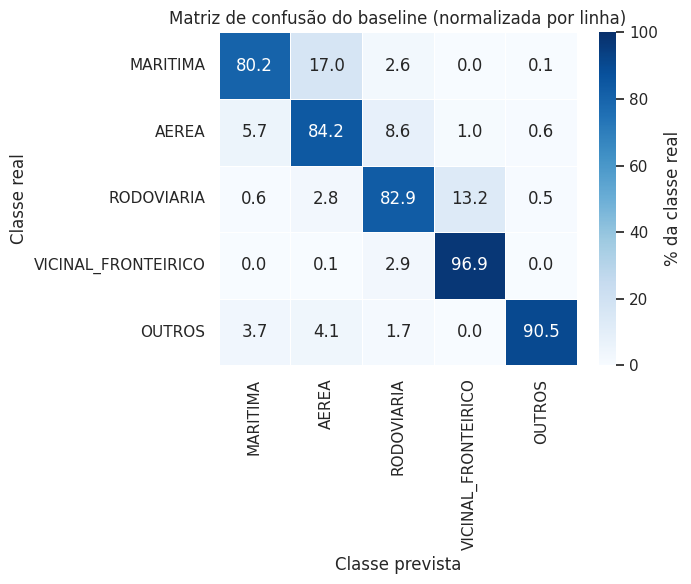

In [15]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_baseline, labels=CLASS_ORDER, normalize='true')

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm * 100, annot=True, fmt='.1f', cmap='Blues', vmin=0, vmax=100,
            xticklabels=CLASS_ORDER, yticklabels=CLASS_ORDER,
            linewidths=0.5, linecolor='white',
            cbar_kws={'label': '% da classe real'}, ax=ax)
ax.set_xlabel('Classe prevista')
ax.set_ylabel('Classe real')
ax.set_title('Matriz de confusão do baseline (normalizada por linha)')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'baseline_confusion_matrix.png', dpi=140, bbox_inches='tight')
plt.show()

Interpretação do baseline.

O F1-macro de 0,65 e a acurácia de 0,82 são a referência para as próximas etapas. Os três modais principais já são bem classificados (F1 entre 0,77 e 0,88).

O class_weight balanced cumpre seu papel de dar visibilidade às classes raras: VICINAL_FRONTEIRICO e OUTROS têm recall altíssimo (97% e 90%), ou seja, o modelo encontra quase todos os casos. Em compensação, a precisão dessas duas classes é baixa (0,31 e 0,20): para não perder os casos raros, o modelo acaba prevendo essas classes em excesso, gerando muitos falsos positivos. É isso que puxa o F1-macro para baixo.

As confusões mais relevantes são MARITIMA prevista como AEREA (17%) e RODOVIARIA prevista como VICINAL_FRONTEIRICO (13%).

O tuning da próxima seção vai buscar melhorar o F1-macro, principalmente equilibrando a precisão das classes minoritárias.

## 5. Otimização de hiperparâmetros (RandomizedSearchCV)

A busca de hiperparâmetros é feita com RandomizedSearchCV, que sorteia combinações aleatórias do espaço de busca em vez de testar todas, como faria o GridSearchCV. Em um espaço grande como o do LightGBM, a busca aleatória encontra boas configurações a uma fração do custo.

Para manter o tempo viável em 1,35 milhão de linhas, a validação cruzada roda sobre uma amostra estratificada de 150 mil registros do treino, preservando as proporções das classes. A melhor configuração encontrada é depois retreinada no conjunto de treino completo e avaliada no conjunto de teste.

Configuração: validação cruzada estratificada com 3 folds, 15 combinações sorteadas, métrica F1-macro e random_state 42.

In [16]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

# Amostra estratificada do treino, usada apenas na busca para acelerar a validacao cruzada
X_search, _, y_search, _ = train_test_split(
    X_train, y_train, train_size=150_000, random_state=RANDOM_STATE, stratify=y_train)

param_distributions = {
    'n_estimators': [200, 300, 400],
    'learning_rate': [0.02, 0.05, 0.1],
    'num_leaves': [31, 63, 127],
    'max_depth': [-1, 8, 12],
    'min_child_samples': [20, 50, 100],
    'subsample': [0.7, 0.8, 1.0],
    'subsample_freq': [1],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'reg_alpha': [0.0, 0.1, 1.0],
    'reg_lambda': [0.0, 0.1, 1.0],
}

search_estimator = LGBMClassifier(
    objective='multiclass', class_weight='balanced',
    random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)

search = RandomizedSearchCV(
    search_estimator, param_distributions, n_iter=15,
    scoring='f1_macro',
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE),
    random_state=RANDOM_STATE, n_jobs=1, verbose=2)
search.fit(X_search, y_search)

print(f'Melhor F1-macro (CV na amostra): {search.best_score_:.4f}')
print('Melhores hiperparametros:')
for k, v in search.best_params_.items():
    print(f'  {k}: {v}')

Fitting 3 folds for each of 15 candidates, totalling 45 fits


[CV] END colsample_bytree=1.0, learning_rate=0.05, max_depth=-1, min_child_samples=100, n_estimators=200, num_leaves=31, reg_alpha=0.0, reg_lambda=0.0, subsample=0.7, subsample_freq=1; total time=  13.4s


[CV] END colsample_bytree=1.0, learning_rate=0.05, max_depth=-1, min_child_samples=100, n_estimators=200, num_leaves=31, reg_alpha=0.0, reg_lambda=0.0, subsample=0.7, subsample_freq=1; total time=  11.9s


[CV] END colsample_bytree=1.0, learning_rate=0.05, max_depth=-1, min_child_samples=100, n_estimators=200, num_leaves=31, reg_alpha=0.0, reg_lambda=0.0, subsample=0.7, subsample_freq=1; total time=  13.2s


[CV] END colsample_bytree=0.7, learning_rate=0.02, max_depth=8, min_child_samples=20, n_estimators=300, num_leaves=63, reg_alpha=1.0, reg_lambda=0.1, subsample=1.0, subsample_freq=1; total time=  30.2s


...

[CV] END colsample_bytree=0.7, learning_rate=0.02, max_depth=8, min_child_samples=20, n_estimators=200, num_leaves=63, reg_alpha=0.1, reg_lambda=0.1, subsample=0.8, subsample_freq=1; total time=  21.8s


[CV] END colsample_bytree=0.7, learning_rate=0.05, max_depth=-1, min_child_samples=50, n_estimators=200, num_leaves=31, reg_alpha=0.0, reg_lambda=0.1, subsample=0.7, subsample_freq=1; total time=  15.9s


[CV] END colsample_bytree=0.7, learning_rate=0.05, max_depth=-1, min_child_samples=50, n_estimators=200, num_leaves=31, reg_alpha=0.0, reg_lambda=0.1, subsample=0.7, subsample_freq=1; total time=  18.3s


[CV] END colsample_bytree=0.7, learning_rate=0.05, max_depth=-1, min_child_samples=50, n_estimators=200, num_leaves=31, reg_alpha=0.0, reg_lambda=0.1, subsample=0.7, subsample_freq=1; total time=  15.3s


Melhor F1-macro (CV na amostra): 0.6680
Melhores hiperparametros:
  subsample_freq: 1
  subsample: 1.0
  reg_lambda: 0.1
  reg_alpha: 1.0
  num_leaves: 31
  n_estimators: 400
  min_child_samples: 50
  max_depth: -1
  learning_rate: 0.1
  colsample_bytree: 0.8


In [17]:
# Retreina a melhor configuracao no conjunto de treino completo
best_params = search.best_params_
tuned = LGBMClassifier(
    objective='multiclass', class_weight='balanced',
    random_state=RANDOM_STATE, n_jobs=-1, verbose=-1, **best_params)
tuned.fit(X_train, y_train)

y_pred_tuned = tuned.predict(X_test)
f1_macro_tuned = f1_score(y_test, y_pred_tuned, average='macro')
acc_tuned = accuracy_score(y_test, y_pred_tuned)

print(f'F1-macro (tuned): {f1_macro_tuned:.4f}')
print(f'Acuracia (tuned): {acc_tuned:.4f}')
print()
print(classification_report(y_test, y_pred_tuned, labels=CLASS_ORDER, digits=4, zero_division=0))

F1-macro (tuned): 0.6960
Acuracia (tuned): 0.8345



                     precision    recall  f1-score   support

           MARITIMA     0.9665    0.8170    0.8855    182752
              AEREA     0.7223    0.8557    0.7834     93349
         RODOVIARIA     0.8015    0.8477    0.8240     58191
VICINAL_FRONTEIRICO     0.3337    0.9465    0.4935      3983
             OUTROS     0.3565    0.8027    0.4937       294

           accuracy                         0.8345    338569
          macro avg     0.6361    0.8539    0.6960    338569
       weighted avg     0.8629    0.8345    0.8418    338569



In [18]:
# Comparacao antes (baseline) e depois (tuned), geral e por classe
f1_base = f1_score(y_test, y_pred_baseline, labels=CLASS_ORDER, average=None, zero_division=0)
f1_tuned = f1_score(y_test, y_pred_tuned, labels=CLASS_ORDER, average=None, zero_division=0)

compare = pd.DataFrame({'baseline': f1_base, 'tuned': f1_tuned}, index=CLASS_ORDER)
compare.loc['F1-MACRO'] = [f1_macro_baseline, f1_macro_tuned]
compare.loc['ACURACIA'] = [acc_baseline, acc_tuned]
compare['delta'] = compare['tuned'] - compare['baseline']
compare.round(4)

,baseline,tuned,delta
MARITIMA,0.8752,0.8855,0.0103
AEREA,0.7677,0.7834,0.0157
RODOVIARIA,0.8081,0.8240,0.0159
VICINAL_FRONTEIRICO,0.4695,0.4935,0.0240
OUTROS,0.3288,0.4937,0.1649
F1-MACRO,0.6499,0.6960,0.0462
ACURACIA,0.8197,0.8345,0.0147


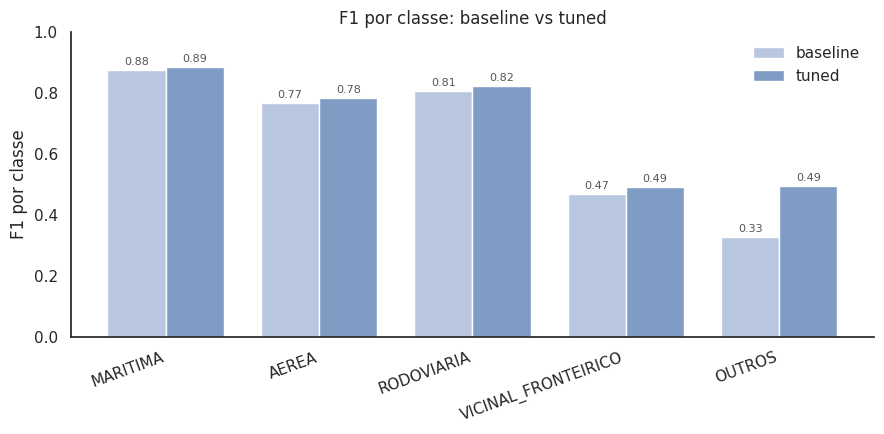

In [19]:
# F1 por classe: baseline vs tuned
idx = CLASS_ORDER
base_vals = compare.loc[idx, 'baseline'].values
tuned_vals = compare.loc[idx, 'tuned'].values
pos = np.arange(len(idx))
w = 0.38

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(pos - w/2, base_vals, w, label='baseline', color='#b9c6e0')
ax.bar(pos + w/2, tuned_vals, w, label='tuned', color='#7f9cc4')
ax.set_xticks(pos)
ax.set_xticklabels(idx, rotation=20, ha='right')
ax.set_ylabel('F1 por classe')
ax.set_ylim(0, 1)
ax.set_title('F1 por classe: baseline vs tuned')
ax.legend(frameon=False)
for p, b, t in zip(pos, base_vals, tuned_vals):
    ax.text(p - w/2, b + 0.01, f'{b:.2f}', ha='center', va='bottom', fontsize=8, color='#555555')
    ax.text(p + w/2, t + 0.01, f'{t:.2f}', ha='center', va='bottom', fontsize=8, color='#555555')
sns.despine()
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'baseline_vs_tuned_f1.png', dpi=140, bbox_inches='tight')
plt.show()

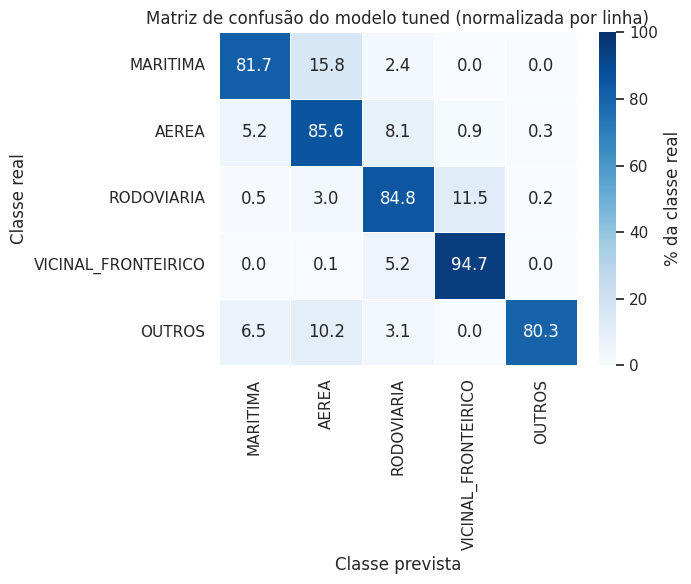

In [20]:
# Matriz de confusao do modelo tuned (normalizada por linha)
cm_tuned = confusion_matrix(y_test, y_pred_tuned, labels=CLASS_ORDER, normalize='true')

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm_tuned * 100, annot=True, fmt='.1f', cmap='Blues', vmin=0, vmax=100,
            xticklabels=CLASS_ORDER, yticklabels=CLASS_ORDER,
            linewidths=0.5, linecolor='white',
            cbar_kws={'label': '% da classe real'}, ax=ax)
ax.set_xlabel('Classe prevista')
ax.set_ylabel('Classe real')
ax.set_title('Matriz de confusão do modelo tuned (normalizada por linha)')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'tuned_confusion_matrix.png', dpi=140, bbox_inches='tight')
plt.show()

Interpretação do tuning.

O tuning melhorou o F1-macro de 0,65 para 0,70 (ganho de 0,046), com todas as classes melhorando e nenhuma piorando. A acurácia subiu de 0,82 para 0,83.

O maior ganho foi na classe OUTROS, cujo F1 saltou de 0,33 para 0,49. A precisão dessa classe subiu de 0,20 para 0,36, ou seja, o modelo tunado reduziu bastante os falsos positivos na classe mais difícil, que era o ponto mais fraco do baseline.

As três classes principais tiveram ganhos menores, porém consistentes (entre 0,010 e 0,016 de F1), já que o baseline já as classificava bem.

Na matriz de confusão do modelo tunado, a diagonal permanece forte e as confusões principais continuam sendo MARITIMA prevista como AEREA (15,8%) e RODOVIARIA prevista como VICINAL_FRONTEIRICO (11,5%), o que reflete a semelhança real entre esses modais.

A melhor configuração encontrada foi: n_estimators 400, learning_rate 0.1, num_leaves 31, max_depth -1, min_child_samples 50, subsample 1.0, colsample_bytree 0.8, reg_alpha 1.0 e reg_lambda 0.1.

Tempo de execução do notebook.

Nesta execução, em uma máquina utilizando cerca de 4 núcleos de CPU, o notebook completo levou aproximadamente 16 a 18 minutos do início ao fim. A etapa mais custosa é a busca de hiperparâmetros com RandomizedSearchCV, responsável por cerca de 14 minutos (45 treinos de validação cruzada, em média 19 segundos cada). O tempo total depende do hardware utilizado.

## 6. Interpretabilidade e a Hipótese 2

A H2 afirma que as características físicas da carga (net_weight_kg) e a origem geográfica (origin_state) são os preditores de maior peso para a via de transporte, superando o valor declarado (fob_value_usd).

Para avaliar isso, são usadas duas medidas de importância das features do modelo tunado:

1. Importância por ganho (gain), nativa do LightGBM: quanto cada feature reduz a perda nas divisões em que é usada.
2. Permutation importance: a queda no F1-macro quando os valores de uma feature são embaralhados no conjunto de teste. É uma medida mais robusta, pois reflete o impacto real na generalização. Calculada sobre uma amostra de 50 mil registros do teste, com 5 repetições.

In [21]:
# Importancia por ganho (gain) nativa do LightGBM, no modelo tunado
imp_gain = pd.DataFrame({
    'feature': tuned.booster_.feature_name(),
    'gain': tuned.booster_.feature_importance(importance_type='gain'),
})
imp_gain['gain_%'] = (imp_gain['gain'] / imp_gain['gain'].sum() * 100).round(2)
imp_gain = imp_gain.sort_values('gain', ascending=False).reset_index(drop=True)
imp_gain

,feature,gain,gain_%
0,country_code,"9,599,431.0513",49.1800
1,ncm_chapter,"4,534,627.6224",23.2300
2,value_per_kg,"1,856,725.1681",9.5100
3,origin_state,"1,480,860.8708",7.5900
4,fob_value_usd,"884,363.9057",4.5300
5,net_weight_kg,"607,404.4124",3.1100
6,month,"413,938.6333",2.1200
7,statistical_unit_code_export,"140,419.1064",0.7200


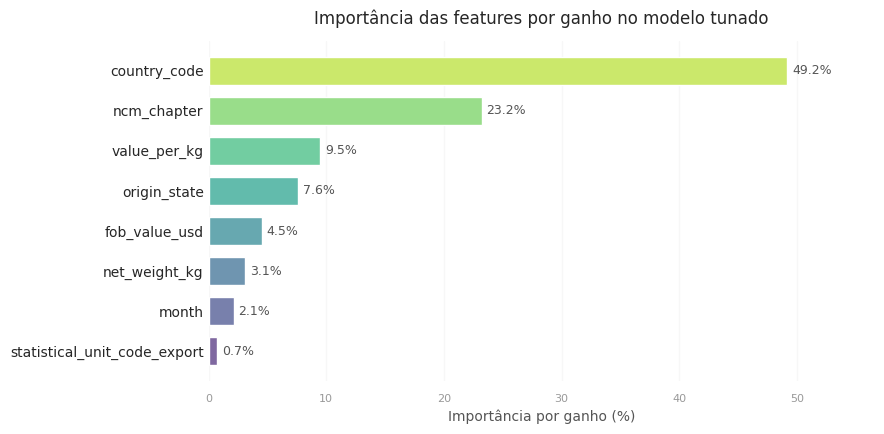

In [22]:
# Grafico da importancia por ganho
order = imp_gain.sort_values('gain_%')
colors = [lighten(c, 0.3) for c in sns.color_palette('viridis', len(order))]
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.barh(order['feature'], order['gain_%'], color=colors, edgecolor='white', height=0.7)
for i, v in enumerate(order['gain_%']):
    ax.text(v + 0.4, i, f'{v:.1f}%', va='center', fontsize=9, color='#555555')
ax.set_xlim(right=order['gain_%'].max() * 1.15)
ax.set_xlabel('Importância por ganho (%)', fontsize=10, color='#555555')
ax.set_title('Importância das features por ganho no modelo tunado', fontsize=12, pad=12)
ax.tick_params(axis='y', length=0, labelsize=10)
ax.tick_params(axis='x', colors='#999999', labelsize=8)
sns.despine(left=True, bottom=True)
ax.grid(axis='x', alpha=0.15)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'feature_importance_gain.png', dpi=140, bbox_inches='tight')
plt.show()

In [23]:
from sklearn.inspection import permutation_importance

# Amostra estratificada do teste para acelerar a permutation importance
X_perm, _, y_perm, _ = train_test_split(
    X_test, y_test, train_size=50_000, random_state=RANDOM_STATE, stratify=y_test)
perm = permutation_importance(
    tuned, X_perm, y_perm, scoring='f1_macro', n_repeats=5,
    random_state=RANDOM_STATE, n_jobs=1)
imp_perm = pd.DataFrame({
    'feature': list(X_perm.columns),
    'queda_f1_macro': perm.importances_mean.round(4),
    'desvio': perm.importances_std.round(4),
}).sort_values('queda_f1_macro', ascending=False).reset_index(drop=True)
imp_perm

,feature,queda_f1_macro,desvio
0,country_code,0.3421,0.0082
1,ncm_chapter,0.1080,0.0064
2,origin_state,0.0666,0.0041
3,net_weight_kg,0.0570,0.0026
4,value_per_kg,0.0491,0.0076
5,fob_value_usd,0.0304,0.0078
6,month,0.0136,0.0013
7,statistical_unit_code_export,0.0067,0.0016


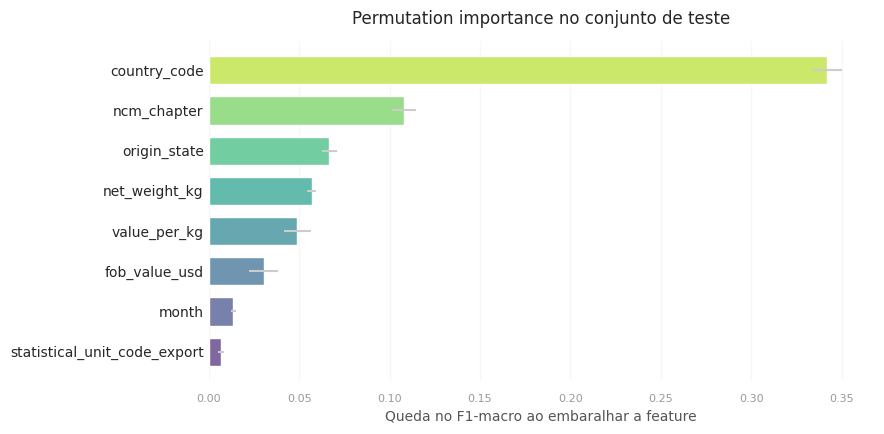

In [24]:
# Grafico da permutation importance
order = imp_perm.sort_values('queda_f1_macro')
colors = [lighten(c, 0.3) for c in sns.color_palette('viridis', len(order))]
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.barh(order['feature'], order['queda_f1_macro'], xerr=order['desvio'],
        color=colors, edgecolor='white', height=0.7, error_kw={'ecolor': '#cccccc'})
ax.set_xlabel('Queda no F1-macro ao embaralhar a feature', fontsize=10, color='#555555')
ax.set_title('Permutation importance no conjunto de teste', fontsize=12, pad=12)
ax.tick_params(axis='y', length=0, labelsize=10)
ax.tick_params(axis='x', colors='#999999', labelsize=8)
sns.despine(left=True, bottom=True)
ax.grid(axis='x', alpha=0.15)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'feature_importance_permutation.png', dpi=140, bbox_inches='tight')
plt.show()

Avaliação da Hipótese 2.

As duas medidas concordam que os preditores dominantes são o país de destino (country_code) e o tipo de produto (ncm_chapter), bem à frente das demais features. Pela importância por ganho, country_code responde por 49,2% e ncm_chapter por 23,2%; pela permutation importance, embaralhar country_code derruba o F1-macro em 0,34 e ncm_chapter em 0,11. Isso é coerente com o domínio: o destino restringe os modais viáveis (um vizinho fronteiriço favorece o rodoviário, um destino transoceânico favorece o marítimo ou o aéreo) e o tipo de mercadoria está ligado à forma como ela é transportada.

Quanto à H2 especificamente, o resultado é parcialmente confirmado:

1. origin_state supera fob_value_usd nas duas medidas (ganho 7,6% contra 4,5%; permutation 0,067 contra 0,031).
2. net_weight_kg supera fob_value_usd na permutation importance (0,057 contra 0,031), que é a medida mais confiável, mas não na importância por ganho (3,1% contra 4,5%).
3. Por outro lado, a parte da H2 que coloca peso e origem como os preditores mais fortes não se sustenta: ambos ficam atrás de country_code e ncm_chapter.

Conclusão: a H2 acerta ao afirmar que origem e peso pesam mais que o valor declarado, com a ressalva de que para o peso isso vale na permutation importance e não no ganho. Mas a H2 erra ao supor que essas características físicas e geográficas seriam as mais determinantes. O modelo indica que a escolha do modal é guiada sobretudo pelo destino e pelo tipo de produto.

## 7. Comparação final dos modelos

Esta seção reúne os três algoritmos do projeto em uma única comparação: Regressão Logística, Random Forest e LightGBM. Para que a comparação seja justa, todos foram avaliados sob o mesmo protocolo: a mesma base, o mesmo alvo de 5 classes (após remover a via não declarada), a mesma divisão 80/20 estratificada (conjunto de teste com 338.569 operações) e as mesmas oito variáveis de entrada. Os resultados da Regressão Logística e do Random Forest vêm do notebook logreg_rf_modeling.ipynb; os do LightGBM são os calculados neste notebook.

As métricas usadas são a acurácia (proporção de acertos no total), o F1-macro (média do F1 por classe, tratando todas igualmente, métrica principal por causa do desbalanceamento) e o F1-weighted (média do F1 ponderada pelo tamanho de cada classe).

In [25]:
from sklearn.metrics import f1_score

# Regressao Logistica e Random Forest: resultados obtidos no notebook logreg_rf_modeling.ipynb,
# sob o MESMO protocolo (mesma base, mesmo alvo de 5 classes, mesma divisao 80/20 estratificada
# e as mesmas 8 features). LightGBM: calculado neste notebook.
externos = [
    {'Modelo': 'Regressão Logística',      'Acuracia': 0.7254, 'F1-macro': 0.5226, 'F1-weighted': 0.7500},
    {'Modelo': 'Random Forest (baseline)', 'Acuracia': 0.7465, 'F1-macro': 0.5366, 'F1-weighted': 0.7659},
    {'Modelo': 'Random Forest (tunado)', 'Acuracia': 0.8318, 'F1-macro': 0.6749, 'F1-weighted': 0.8395},
]

lgbm = [
    {'Modelo': 'LightGBM (baseline)', 'Acuracia': acc_baseline, 'F1-macro': f1_macro_baseline,
     'F1-weighted': f1_score(y_test, y_pred_baseline, average='weighted')},
    {'Modelo': 'LightGBM (tunado)', 'Acuracia': acc_tuned, 'F1-macro': f1_macro_tuned,
     'F1-weighted': f1_score(y_test, y_pred_tuned, average='weighted')},
]

comparison = pd.DataFrame(externos + lgbm)
comparison.round(4)

,Modelo,Acuracia,F1-macro,F1-weighted
0,Regressão Logística,0.7254,0.5226,0.7500
1,Random Forest (baseline),0.7465,0.5366,0.7659
2,Random Forest (tunado),0.8318,0.6749,0.8395
3,LightGBM (baseline),0.8197,0.6499,0.8288
4,LightGBM (tunado),0.8345,0.6960,0.8418


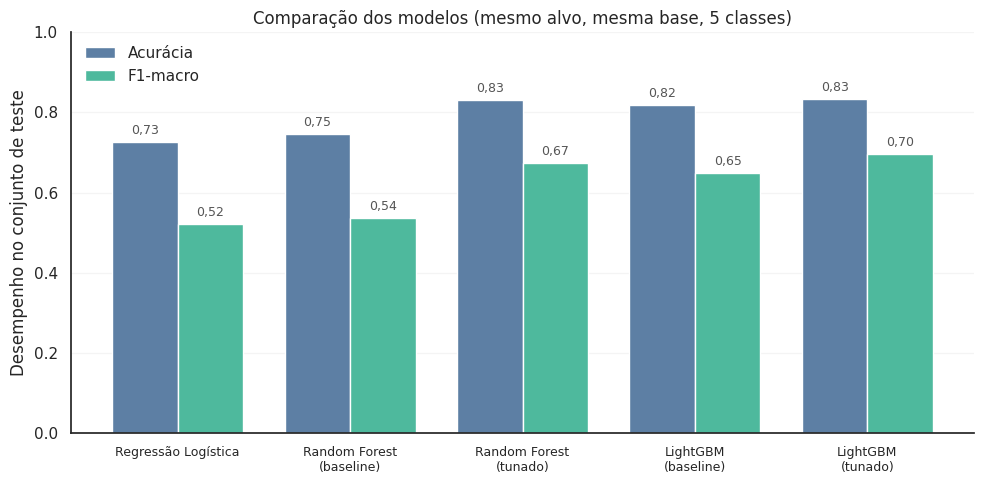

In [26]:
# Grafico de comparacao (acuracia e F1-macro), paleta viridis clara
labels = [m.replace(' (', '\n(') for m in comparison['Modelo']]
x = np.arange(len(labels))
w = 0.38
cmap = plt.cm.viridis

fig, ax = plt.subplots(figsize=(10, 5))
b1 = ax.bar(x - w/2, comparison['Acuracia'], w, label='Acurácia', color=lighten(cmap(0.30), 0.2))
b2 = ax.bar(x + w/2, comparison['F1-macro'], w, label='F1-macro', color=lighten(cmap(0.60), 0.2))
for bars in (b1, b2):
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.012,
                f'{h:.2f}'.replace('.', ','), ha='center', va='bottom',
                fontsize=9, color='#555555')

ax.set_ylim(0, 1.0)
ax.set_ylabel('Desempenho no conjunto de teste')
ax.set_title('Comparação dos modelos (mesmo alvo, mesma base, 5 classes)')
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=9)
ax.legend(loc='upper left', frameon=False)
sns.despine()
ax.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'model_comparison.png', dpi=140, bbox_inches='tight')
plt.show()

Interpretação da comparação.

O desempenho cresce com a complexidade do algoritmo: a Regressão Logística (baseline linear) tem o menor F1-macro, o Random Forest melhora, e o LightGBM obtém o melhor resultado. O ajuste de hiperparâmetros melhora os dois ensembles. O melhor modelo é o LightGBM tunado, com F1-macro de 0,70 e acurácia de 0,83, seguido de perto pelo Random Forest tunado.

Em todos os modelos o F1-macro fica bem abaixo do F1-weighted. Isso mostra que eles classificam bem as classes grandes (marítima, aérea e rodoviária) e ainda têm dificuldade com as classes raras (vicinal fronteiriço e outros), o que é esperado dado o forte desbalanceamento do alvo.